## Figure 10. Storm direction Trend analysis 

In [2]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [3]:
# import plottig functions
from pathlib import Path
import sys
# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.diagnostic_plots import circular_percentile, circular_mean, circular_trend, circular_trend_permutation_test

In [4]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

In [5]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

domains = pd.DataFrame(index=grid['D_name'], columns=["x", "y"])
domains["x"] = xs
domains["y"] = ys

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_61332/4044105814.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.geometry.centroid


In [6]:
## function for domain stats
def _month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Fall'


def _compute_variable_stats(df_subset, key, perform_direction_trend=False):
    row = {}

    if key == 'dir':
        directions = df_subset['storm_direction'].dropna()
        if directions.empty:
            return row

        row['mean'] = circular_mean(directions)
        row['median'] = circular_percentile(directions, 50)
        row['p75'] = circular_percentile(directions, 75)
        row['p25'] = circular_percentile(directions, 25)
        row['p5'] = circular_percentile(directions, 5)
        row['p95'] = circular_percentile(directions, 95)
        row['max'] = directions.max()
        row['min'] = directions.min()

        if perform_direction_trend:
            df_year = df_subset.resample('YE').apply(lambda x: x.loc[x['mean_intensity'].idxmax()])
            x = np.arange(len(df_year))
            if len(df_year) > 1 and df_year['storm_direction'].nunique() > 1:
                results = circular_trend_permutation_test(x, df_year['storm_direction'], n_permutations=10000)
                row['trend'] = results['rate_direction_deg']
                row['p_value'] = results['p_value']
            else:
                row['trend'] = np.nan
                row['p_value'] = np.nan

    elif key == 'speed':
        values = df_subset['storm_velocity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'intensity':
        values = df_subset['mean_intensity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'area':
        values = df_subset['area'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'angular_var':
        values = df_subset['angular_variance_weighted'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)

    return row


def compute_stats_by_season(df, key, perform_direction_trend=False):
    season_groups = {'ALL': df}
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_groups[season] = df[df['season'] == season]

    seasonal_stats = {}
    for season_name, season_df in season_groups.items():
        seasonal_stats[season_name] = _compute_variable_stats(
            season_df,
            key,
            perform_direction_trend=(perform_direction_trend and season_name == 'ALL'),
        )
    return seasonal_stats


def domain_stats_func(top_storms, perform_direction_trend=False):
    variable_keys = ['dir', 'speed', 'intensity', 'area', 'angular_var']
    season_keys = ['ALL', 'Winter', 'Spring', 'Summer', 'Fall']
    stats = {key: {season: pd.DataFrame() for season in season_keys} for key in variable_keys}

    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()

        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        df['season'] = df.index.month.map(_month_to_season)

        domain_x = domains.loc[cat]['x']
        domain_y = domains.loc[cat]['y']

        for key in variable_keys:
            seasonal_stats = compute_stats_by_season(
                df,
                key,
                perform_direction_trend=perform_direction_trend,
            )

            for season_name, values in seasonal_stats.items():
                for stat_name, stat_value in values.items():
                    stats[key][season_name].loc[cat, stat_name] = stat_value
                stats[key][season_name].loc[cat, 'centroid_x'] = domain_x
                stats[key][season_name].loc[cat, 'centroid_y'] = domain_y

    for key in variable_keys:
        for season_name in season_keys:
            stats[key][season_name].reset_index(inplace=True)
            stats[key][season_name].rename(columns={'index': 'Domain'}, inplace=True)

    return stats

## Direction trend plot function

In [7]:

from matplotlib.patches import Circle, FancyArrow, FancyArrowPatch
from matplotlib.colors import Normalize
from matplotlib import cm
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


colors = [
    (0.0, '#08306b'),   # dark blue
    (0.15, '#2171b5'),  # blue
    (0.3, '#6baed6'),   # light blue
    (0.35, '#c6dbef'),  # very light blue
    (0.5, '#ffffff'),   # white center
    (0.65, '#fcbba1'),  # very light red
    (0.7, '#fb6a4a'),   # light red
    (0.85, '#cb181d'),  # red
    (1.0, '#67000d'),   # dark red
]

cmap_custom = LinearSegmentedColormap.from_list(
    'BlueWhiteRed',
    [(pos, color) for pos, color in colors])

def plot_colored_circle_with_arrow(
    ax,
    centroid,             # (x, y)
    value,                # numeric value for circle color
    angle_deg,            # 0–360 deg; 0 = +x (east), CCW positive
    *,
    valor_rotacion=0.0,   # > 0 CCW, < 0 CW, 0 = no rotation arrow
    radius=1.6,
    vmin=None, vmax=None, # color normalization range
    cmap='custom_blue_red',
    edgecolor='black',
    linewidth=0.5,
    arrow_scale=0.8,      # arrow length = radius * arrow_scale
    arrow_width=0.01,     # in data units
    show_outline=True,
    zorder=3,
    # --- NEW hatch controls ---
    p_value=None,                 # if not None and < hatch_if_below -> add hatch
    hatch_if_below=0.05,
    hatch_pattern='////',
    hatch_edgecolor='black'       # used to make hatch visible if show_outline=False
):
    """
    Draw a colored circle with an internal directional arrow and optional rotation arrow.
    NEW: If p_value is provided and p_value < hatch_if_below, apply a hatch on the circle.

    Returns
    -------
    (circle_patch, arrow_patch, rotation_arrow_patch)
    rotation_arrow_patch is None if valor_rotacion == 0.
    """
    x, y = centroid

    # ---- Color normalization ----
    if vmin is None or vmax is None:
        vmin = value if vmin is None else vmin
        vmax = value if vmax is None else vmax
        if vmin == vmax:  # avoid zero range
            vmin -= 1.0
            vmax += 1.0

    
    if cmap == 'custom_blue_red':
        colors = [
            (0.0, '#08306b'),   # dark blue
            (0.15, '#2171b5'),  # blue
            (0.3, '#6baed6'),   # light blue
            (0.35, '#c6dbef'),  # very light blue
            (0.5, '#ffffff'),   # white center
            (0.65, '#fcbba1'),  # very light red
            (0.7, '#fb6a4a'),   # light red
            (0.85, '#cb181d'),  # red
            (1.0, '#67000d'),   # dark red
        ]

        cmap = LinearSegmentedColormap.from_list(
            'BlueWhiteRed',
            [(pos, color) for pos, color in colors])

  
    norm = Normalize(vmin=vmin, vmax=vmax)
    color = cmap(norm(value))

    # ---- Circle ----
    circle = Circle((x, y), radius=radius, facecolor=color,
                    edgecolor=edgecolor if show_outline else color,
                    linewidth=linewidth, zorder=zorder)
    ax.add_patch(circle)

    # Apply hatch if requested by p_value
    if (p_value is not None) and (p_value < hatch_if_below):
        circle.set_hatch(hatch_pattern)
        # Ensure hatch is visible even when show_outline=False
        if not show_outline:
            circle.set_edgecolor(hatch_edgecolor)
            # a thin edge helps render the hatch; keep user's linewidth otherwise
            if linewidth == 0:
                circle.set_linewidth(0.8)

    # ---- Internal directional arrow ----
    ang = np.deg2rad(angle_deg % 360.0)
    L = radius * arrow_scale
    dx, dy = L * np.cos(ang), L * np.sin(ang)
    arrow = ax.annotate(
        '',
        xy=(x + dx, y + dy),
        xytext=(x, y),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            lw=2.5,
            shrinkA=0,
            shrinkB=0
        ),
        zorder=zorder + 1
    )

    # ---- Rotation arrow (exterior) ----
    if valor_rotacion == 0.0:
        return circle, arrow, None

    arc_radius = radius * 1.3
    ang_10 = np.deg2rad(150)
    ang_2  = np.deg2rad(30)
    pos_10 = (x + arc_radius * np.cos(ang_10), y + arc_radius * np.sin(ang_10))
    pos_2  = (x + arc_radius * np.cos(ang_2),  y + arc_radius * np.sin(ang_2))

    # Direction convention from your original: sign(value) picks CW/CCW
    if value > 0:
        posA, posB, rad_curve = pos_2, pos_10,  0.4   # CCW
    else:
        posA, posB, rad_curve = pos_10, pos_2, -0.4   # CW

    rot_arrow = FancyArrowPatch(
        posA, posB,
        connectionstyle=f"arc3,rad={rad_curve}",
        arrowstyle='->',
        mutation_scale=15,
        color='#444444',
        lw=1.5,
        zorder=zorder - 1
    )
    ax.add_patch(rot_arrow)

    return circle, arrow, rot_arrow




In [8]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

In [24]:
def draw_circle_legend(
    ax=None,
    *,
    # angles for the two columns (deg)
    angles=(30, 210),
    # values control both color and rotation direction in your function:
    # >0 => CCW rotation arrow; <0 => CW rotation arrow
    values=(10.0, -10.0),
    # color scaling and style passed through to your function
    vmin=-20.0, vmax=20.0, cmap=sns.diverging_palette(220, 20, sep=10, as_cmap=True),
    radius=0.22,
    arrow_scale=0.8,
    arrow_width=0.05,
    hatch_pattern='////',
    row_labels=("Non significant trend", "Significant trend")
):
    """
    Draws a 2x2 legend of circles using plot_colored_circle_with_arrow:
      - Top row: two rotations with different internal arrow directions.
      - Bottom row: same circles but with a hatch overlay.
      - Row labels at the left.

    Returns (fig, ax).
    """
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
        created_fig = True
    else:
        fig = ax.figure

    # Coordinate box to lay out 2x2 items
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')
    
    # turn off the default axes spines and ticks for a cleaner legend look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax.set_facecolor((1, 1, 1, 0.4))  # almost transparent background for better visibility if overlaid
    # Positions for 2x2 grid (x, y)
    pos = {
        "r1c1": (0.6, 1.5),
        "r1c2": (1.4, 1.5),
        "r2c1": (0.6, 0.5),
        "r2c2": (1.4, 0.5),
    }

    # --- Row 1: two rotations + different internal arrows ---
    # left: CCW (value > 0), right: CW (value < 0)
    # column 1
    plot_colored_circle_with_arrow(
        ax, pos["r1c1"], values[0], angles[0],
        valor_rotacion=1.0,         # show rotation arrow
        radius=radius, vmin=vmin, vmax=vmax, cmap=cmap,
        arrow_scale=arrow_scale, arrow_width=arrow_width,
        zorder=3
    )
    # column 2
    plot_colored_circle_with_arrow(
        ax, pos["r1c2"], values[1], angles[1],
        valor_rotacion=1.0,         # show rotation arrow
        radius=radius, vmin=vmin, vmax=vmax, cmap=cmap,
        arrow_scale=arrow_scale, arrow_width=arrow_width,
        zorder=3
    )

    # --- Row 2: same circles but with a hatch overlay ---
    # We re-use same values/angles (to match row 1), then overlay a hatched face.
    for key, (val, ang) in zip(["r2c1", "r2c2"], [(values[0], angles[0]), (values[1], angles[1])]):
        cx, cy = pos[key]
        plot_colored_circle_with_arrow(
            ax, (cx, cy), val, ang,
            valor_rotacion=1.0,
            radius=radius, vmin=vmin, vmax=vmax, cmap=cmap,
            arrow_scale=arrow_scale, arrow_width=arrow_width,
            zorder=3
        )
        # Hatch overlay (kept under the inner arrow but above the colored face)
        hatch_patch = Circle((cx, cy), radius=radius,
                             facecolor=(1, 1, 1, 0), edgecolor='black',
                             hatch=hatch_pattern, linewidth=1.0, zorder=3.2)
        ax.add_patch(hatch_patch)

    # --- Title labels (left side) ---
    ax.text(1, 1.9, row_labels[0], ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(1, 0.9, row_labels[1],  ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(0.6, 1.2, "clockwise",  ha='center', va='center', fontsize=12)
    ax.text(1.4, 1.2, "anticlockwise",  ha='center', va='center', fontsize=12)
    ax.text(0.6, 0.2, "clockwise",  ha='center', va='center', fontsize=12)
    ax.text(1.4, 0.2, "anticlockwise",  ha='center', va='center', fontsize=12)
    
    return fig, ax

In [37]:
def trend_conus_plot(ax, domain_stats,top_storms):
    # ── 2) Setup plot ─────────────────────────

    ax.set_extent([-126, -64, 22, 52], crs=ccrs.PlateCarree())

    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.2)
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    ax.add_feature(cfeature.OCEAN, alpha=0.3)

    # Optional: grid outline
    grid.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1.5, alpha=0.4, color='red')


    # ── 4) plot_directional_arrow_with_fan
    
    for dom in domain_stats.itertuples():
        plot_colored_circle_with_arrow(
        ax, 
        centroid=(dom.centroid_x, dom.centroid_y),
        value=dom.trend,              # color based on mean value
        angle_deg=dom.mean,            # angle based on mean value
        p_value=dom.p_value,            # <-- will add hatch
        vmin=-5, vmax=5,
        
        hatch_pattern='xxx',
        hatch_edgecolor='grey',     # optional
        show_outline=True,
        arrow_width=0.5
               # hatch still visible via hatch_edgecolor
        )
    
    #put  labels on top of the grid from 1 to 12
    for i in range(1, 13):
        cell = grid[(grid['row_index']==2.0) & (grid['col_index']==float(i-1))]
        x = (cell.right.values[0] + cell.left.values[0]) / 2  
        y = cell.top.values[0] + 0.5
        ax.text(x, y, str(i), fontsize=14, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

      # put labels on left side from the grid from A to E
    for i, letter in enumerate(['A', 'B', 'C', 'D', 'E']):

        if i < 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==0.0)]
        elif i == 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==1.0)]
        else:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==5.0)]
        x = grid.loc[26].left - 0.6
        y = (cell.top.values[0] + cell.bottom.values[0]) / 2
        ax.text(x, y, letter, fontsize=14, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())


    # add axis ticks
    ax.set_xticks(np.arange(-125, -65, 10), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(25, 55, 5), crs=ccrs.PlateCarree())
    ax.tick_params(axis='both', which='major', labelsize=16)
    ## add axis labels
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    ax.set_title(f"Top {top_storms} storms", fontsize=25)

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


(<Figure size 2000x1500 with 3 Axes>, <Axes: >)

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


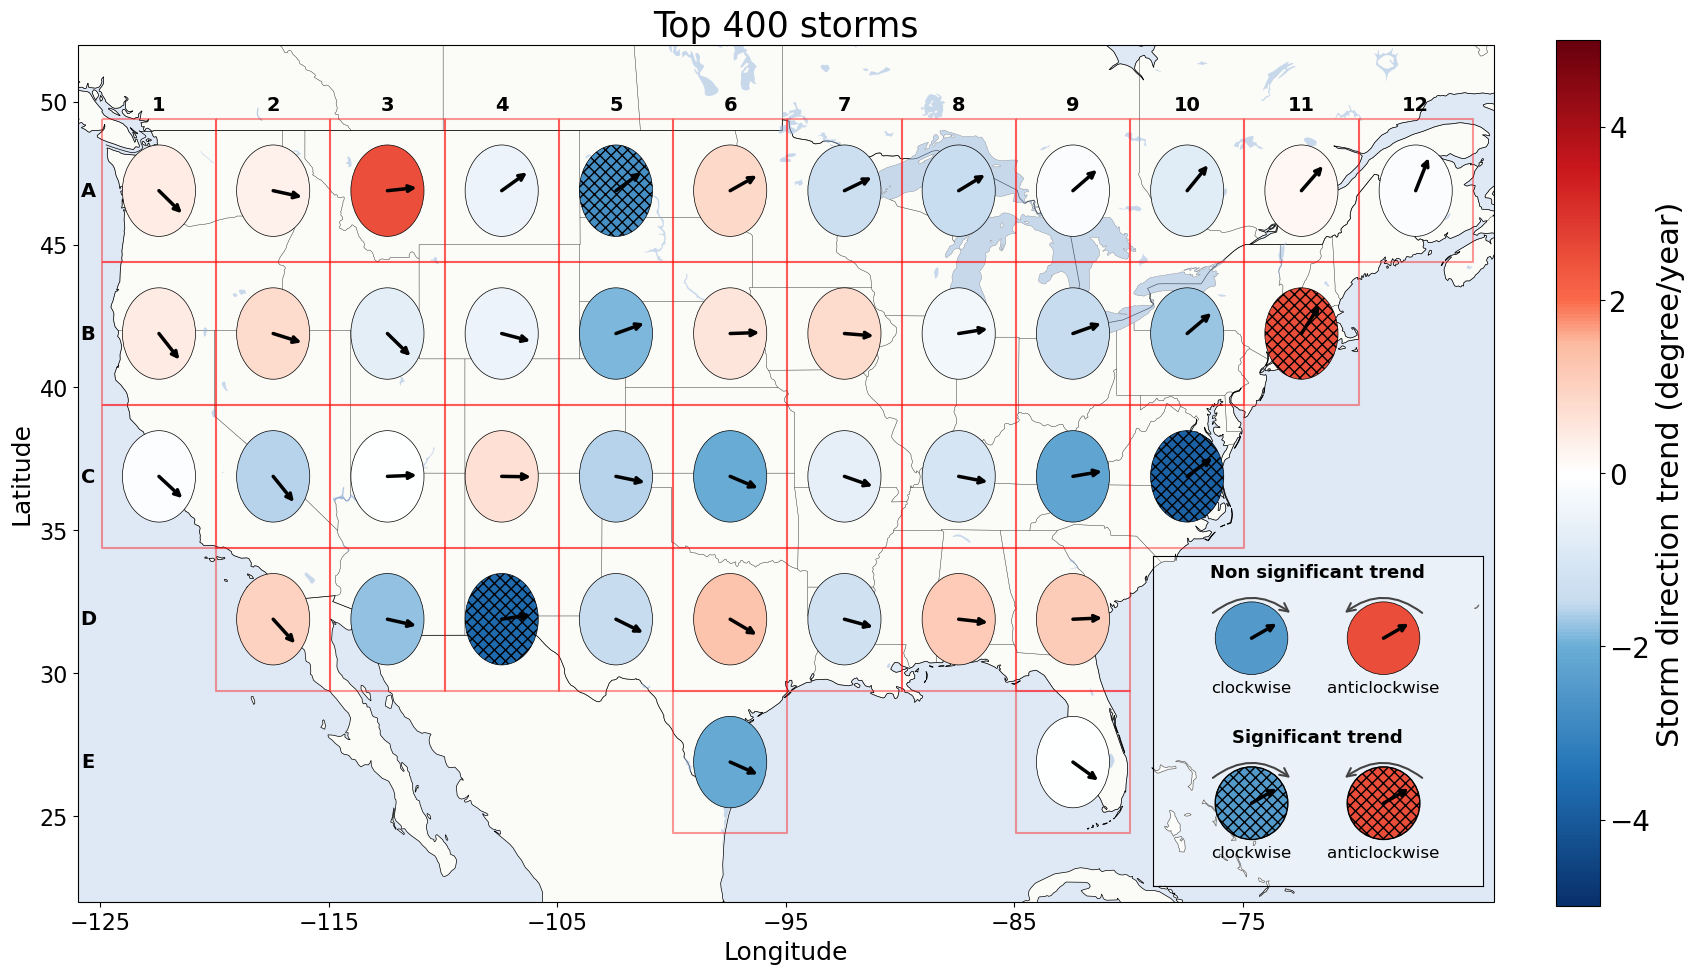

In [38]:
fig, axs = plt.subplots(figsize=(20, 15), subplot_kw={'projection': ccrs.PlateCarree()})
top_storms = 400
#domain_stats_all=domain_stats_func(top_storms, perform_direction_trend=True)

trend_conus_plot(axs, domain_stats_all['dir']['ALL'], top_storms=top_storms)
# add colorbar

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=-5, vmax=5), cmap=cmap_custom)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs, fraction=0.046, pad=0.04, shrink=0.75)
cbar.set_label('Trend Slope')
# 1. Increase the colorbar's main label size
cbar.set_label('Storm direction trend (degree/year)', fontsize=22)

# 2. Increase the colorbar's tick label size (the numbers)
cbar.ax.tick_params(labelsize=20)
ax = fig.add_axes([0.62, 0.22, 0.25, 0.22])
draw_circle_legend(
    ax=ax,
     angles=(30, 30),
     values=(-0.5, 0.5),    # >0 => CCW, <0 => CW in your function
     vmin=-1, vmax=1,
     cmap=cmap_custom,
     hatch_pattern='xxx'
 )


In [12]:
domain_stats_all['dir']['Spring']

,Domain,mean,median,p75,p25,p5,p95,max,min,centroid_x,centroid_y
0,B6,37.796886,39.563029,77.943547,0.095154,292.497588,153.908143,179.206513,-153.075006,-97.437126,41.888331
1,E6,334.022359,331.195639,7.910305,297.851063,248.395001,43.892235,163.992017,-116.923724,-97.437126,26.888331
2,B7,18.242377,19.064499,63.682252,331.571044,272.948886,83.979703,153.284655,-130.443850,-92.437126,41.888331
3,C7,347.374985,344.350148,22.588984,313.791339,261.323057,82.303760,174.708607,-176.487363,-92.437126,36.888331
4,A7,52.566924,55.968597,75.378991,25.634305,336.041801,145.395521,160.359880,-166.665767,-92.437126,46.888331
5,D7,340.627510,338.047805,16.574462,312.284904,264.190343,87.982681,163.230856,-178.623959,-92.437126,31.888331
6,A12,62.354606,78.621171,95.552207,347.782851,297.476053,123.470090,160.595820,-95.340979,-67.437126,46.888331
7,C4,17.556228,30.236656,108.141027,302.589542,234.573629,187.453063,168.895281,-177.809775,-107.437126,36.888331
8,D4,15.332576,16.337519,69.022640,312.204519,259.288958,110.037868,151.620275,-143.396270,-107.437126,31.888331
9,A5,52.936763,58.445407,87.353253,14.679185,339.752336,139.359169,140.053459,-162.785287,-102.437126,46.888331
